In [1]:
import numpy as np # Operacje macierzowe i numeryczne na danych
import matplotlib.pyplot as plt # Wizualizacja wyników, generowanie wykresów i animacji

# Narzędzia do transformacji Fouriera – analiza częstotliwościowa sygnałów/pól (1D i 2D)
from scipy.fft import fft, ifft, fft2, ifft2, fftfreq

# Przetwarzanie sygnałów – wykrywanie maksimów 
from scipy.signal import find_peaks

import time # Pomiar czasu wykonywania komend, służący do oceny wydajności algorytmu

In [2]:
start = time.perf_counter() # Start obliczania czasu tej części algorytmu

# Parametry siatki
Nx = 2**11            # liczba punktów siatki (dobrana jako potęga 2, co optymalizuje działanie algorytmu FFT)
L = 300           # szerokość przestrzeni  (w jednostkach atomowych)
x = np.linspace(-L/2, L/2, Nx) # tworzenie siatki przestrzennej
dx = L / (Nx - 1)         # krok przestrzenny

end = time.perf_counter() # Koniec obliczania czasu tej części algorytmu
print(f"Czas działania: {end - start:.6f} sekundy") # Wyświetlenie czasu działania algorytmu z precyzją mikrosekundową

# Wyświetlenie wartości kroku przestrzennego w celu weryfikacji rozdzielczości siatki
dx

Czas działania: 0.000439 sekundy


0.14655593551538837

In [4]:
start = time.perf_counter()

# --- Definicja wygładzonego potencjału Coulombowskiego (Soft-core Coulomb Potential) ---

# Parametr regulacji osobliwości. Zapobiega rozbieżności potencjału do nieskończoności dla x = 0.
epsilon = 2.0

# Obliczenie wartości potencjału V0(x) na siatce przestrzennej.
# Klasyczny potencjał -1/|x| został zmodyfikowany do postaci -1/sqrt(x^2 + epsilon),
# co eliminuje osobliwość w centrum układu współrzędnych i stabilizuje numerycznie symulację.
V0 = -1 / np.sqrt(x**2 + epsilon)

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 0.000345 sekundy


In [5]:
start = time.perf_counter()

# --- Definicja stanu początkowego elektronu i odczyt danych energetycznych ---

# Wybór numeru (indeksu) stanu własnego, w którym elektron znajduje się w chwili t = 0
# Wartość 8 oznacza wybór ósmego stanu wzbudzonego układu
state_number = 8

# Wczytanie zarchiwizowanych wartości energii własnych wyznaczonych metodą spektralną (Spectral Method)
E_SM = np.load("energie własne E dla Coulomba 1D SM.npy")

# Obliczenie potencjału jonizacji (I_p) dla wybranego stanu własnego,
# czyli jego energii wiązania
I_p = -E_SM[state_number]

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")
print(f'I_p = {I_p}') # Wyświetlenie energii wiązania wybranego stanu własnego

Czas działania: 0.000906 sekundy
I_p = 0.020531143580207595


In [6]:
start = time.perf_counter()

# --- Interpolacja funkcji falowych na nową siatkę przestrzenną ---

# Definicja parametrów pierwotnej siatki, na której obliczono stany własne
Nx_old = 2**10                 # Liczba punktów starej siatki (z SM)
L_old = 140                    # Rozmiar obszaru starej siatki (z SM)
x_old = np.linspace(-L_old/2, L_old/2, Nx_old) # Współrzędne starej siatki (z SM)

# Wczytanie tablicy własnych funkcji falowych (wartości zespolone)
psi_E_SM = np.load("funkcje psi(E) dla Coulomba 1D SM.npy")

# Lista pomocnicza na zainterpolowane funkcje falowe
psi_temp_E = []

# Pętla interpolująca każdą funkcję falową ze starej siatki (x_old) na nową (x)
for i in range(len(psi_E_SM)):
    # Interpolacja liniowa części rzeczywistej z zerowaniem wartości poza starym obszarem
    re = np.interp(x, x_old, psi_E_SM[i].real, left=0, right=0)
    # Interpolacja liniowa części urojonej z zerowaniem wartości poza starym obszarem
    im = np.interp(x, x_old, psi_E_SM[i].imag, left=0, right=0)
    
    # Odtworzenie zespolonej funkcji falowej na nowej siatce
    psi_temp = re + 1j*im
    
    # Ponowna normalizacja funkcji falowej (interpolacja numeryczna może zaburzyć warunek unormowania)
    psi_temp /= np.linalg.norm(psi_temp)
    
    # Dodanie przeliczonej funkcji do listy tymczasowej
    psi_temp_E.append(psi_temp)

# Nadpisanie pierwotnej tablicy nowymi, zainterpolowanymi funkcjami falowymi
psi_E_SM = psi_temp_E

# Czyszczenie pamięci RAM z obiektów tymczasowych
del(x_old)
del(psi_temp_E)

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 0.005132 sekundy


In [7]:
start = time.perf_counter()

# --- Definicja początkowej funkcji falowej układu ---

# Inicjalizacja funkcji falowej ψ jako konkretnego stanu własnego (zgodnie z wartością state_number)
ψ = psi_E_SM[state_number]

# Alternatywny wariant (zakomentowany): Inicjalizacja stanu jako koherentnej superpozycji 
# dwóch, lub więcej, różnych stanów własnych (np. stanu 10. i 8.) w celu badania ewolucji pakietu falowego.
# ψ = psi_E_SM[10] + psi_E_SM[8]

# Warunek normalizacji: Zapewnienie, że całkowite prawdopodobieństwo znalezienia cząstki wynosi 1 
# (wymagane po wykonaniu operacji superpozycji).
# ψ /= np.linalg.norm(ψ)

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 0.000046 sekundy


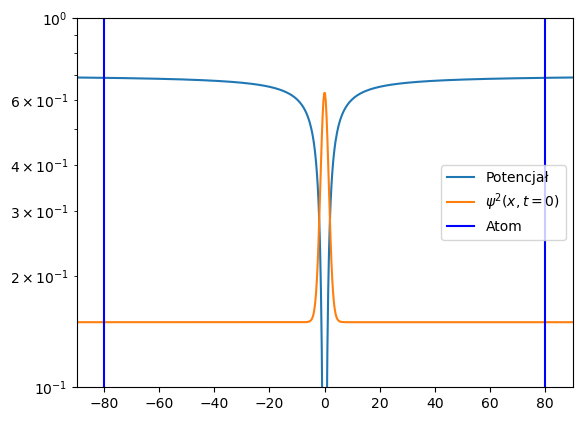

In [125]:
# --- Wykres diagnostyczny stanu początkowego (profil potencjału i gęstość prawdopodobieństwa elektronu) ---

# Rysowanie profilu potencjału Coulomba z przesunięciem pionowym w celu dopasowania do skali wykresu
plt.plot(x, V0 + 0.75, label = "Potencjał")

# Rysowanie gęstości prawdopodobieństwa |ψ|^2 (skalowanej pięciokrotnie dla lepszej widoczności szczegółów)
plt.plot(x, 5*np.abs(ψ)**2 + 0.101, label = "$ψ^2(x, t=0)$")

# Zaznaczenie fizycznych granic atomu, jako 80 promieni Bohra
plt.axvline(x = -80, color = 'b', label = 'Atom')
plt.axvline(x = 80, color = 'b')

# Ograniczenie zakresu osi X w celu odcięcia brzegów siatki i przybliżenia na centrum potencjału
plt.xlim(x.min() + 60, x.max() - 60)

# Ustawienie zakresu osi Y i przełączenie jej na skalę logarytmiczną w celu analizy ogonów asymptotycznych funkcji falowej
plt.ylim(0.1, 1)
plt.yscale('log')

# Wyświetlenie legendy i wygenerowanie wykresu
plt.legend()
plt.show()

In [126]:
start = time.perf_counter()

# --- Parametry fizyczne impulsu laserowego ---
F0 = 0.095          # Maksymalna amplituda natężenia pola elektrycznego lasera (w jednostkach atomowych)
n = 10              # Liczba okresów optycznych wewnątrz obwiedni impulsu
omega_0 = 0.06      # Częstotliwość kołowa fali nośnej lasera (w jednostkach atomowych)
phi = 0             # Faza początkowa fali nośnej

# --- Definicja przedziałów czasowych symulacji ---
# Całkowity czas trwania impulsu laserowego obliczony na podstawie liczby okresów n i częstotliwości omega_0
T_pulse = 2 * np.pi * n / omega_0

# Czas relaksacji układu po wyłączeniu lasera (pozwala na swobodną ewolucję i propagację pakietu falowego)
T_relaxation = 500 + T_pulse / n

# Całkowity czas symulacji (czas impulsu + czas relaksacji) w jednostkach atomowych
T_max = T_pulse + T_relaxation

# --- Dyskretyzacja dziedziny czasu ---
# Liczba kroków czasowych (dobrana jako potęga 2 pod kątem wydajności FFT w dalszych etapach)
Nt = 2**19

# Krok czasowy (rozdzielczość czasowa schematu propagacji)
dt = T_max / (Nt - 1)

# Generowanie jednorodnej siatki punktów czasowych t ∈ [0, T_max]
t_values = np.linspace(0, T_max, Nt)

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 0.002066 sekundy


In [127]:
start = time.perf_counter()

# --- Definicje funkcji obwiedni czasowych impulsu laserowego ---

def envelope_flat_top(t_values, Nt, T_pulse):
    """
    Generuje obwiednię typu 'flat-top' z gładkim włączaniem i wyłączaniem funkcją sin^2.
    Zapewnia łagodne wprowadzenie zaburzenia do układu kwantowego.
    """
    # Inicjalizacja obwiedni jako ciąg zer;
    # obwiednia będzie przyjmowała wartości zerowe dla t > T_pulse 
    f = np.zeros(Nt)

    # Definicja czasów granicznych dla poszczególnych faz impulsu
    t_on = 0.5 * T_pulse / n       # Koniec fazy włączania (trwa pół okresu optycznego)
    t_off = (n-0.5) * T_pulse / n  # Początek fazy wyłączania (pozostaje pół okresu do końca)

    # 1. Faza włączania (turn-on): gładki wzrost amplitudy od 0 do 1
    mask_on = t_values < t_on
    f[mask_on] = np.sin(omega_0 * t_values[mask_on] / 2)**2

    # 2. Faza stacjonarna (flat-top): maksymalne, stałe natężenie pola przez główną część impulsu
    mask_flat = (t_values >= t_on) & (t_values < t_off)
    f[mask_flat] = 1.0

    # 3. Faza wyłączania (turn-off): gładki spadek amplitudy od 1 do 0
    mask_off = (t_values >= t_off) & (t_values < T_pulse)
    f[mask_off] = np.sin(omega_0 * t_values[mask_off] / 2)**2

    return f


def envelope_sin_squared(t_values, Nt, T_pulse):
    """
    Generuje globalną obwiednię typu sin^2 dla całego czasu trwania impulsu.
    Standardowy profil modelujący impulsy ultrakrótkie w fizyce silnych pól laserowych.
    """
    # Inicjalizacja obwiedni jako ciąg zer;
    # obwiednia będzie przyjmowała wartości zerowe dla t > T_pulse
    f = np.zeros(Nt)
    
    # Obliczenie amplitudy obwiedni sin^2(π * t / T_pulse) dla t < T_pulse
    mask = t_values < T_pulse
    f[mask] = np.sin(np.pi * t_values[mask] / T_pulse)**2

    return f
    
end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 0.000436 sekundy


In [128]:
start = time.perf_counter()

# Wygenerowanie wybranej obwiedni czasowej (w tym przypadku profilu sin^2)
f = envelope_sin_squared(t_values, Nt, T_pulse)

# --- Konstrukcja oscylującego pola elektrycznego lasera F(t) ---
F = np.zeros(Nt)

# Obliczenie natężenia pola jako iloczynu amplitudy F0, obwiedni f(t) oraz fali nośnej sin(ωt + φ)
# Pole działa wyłącznie w przedziale czasu [0, T_pulse]
mask_pulse = t_values < T_pulse
F[mask_pulse] = F0 * f[mask_pulse] * np.sin(omega_0 * t_values[mask_pulse] + phi)

# Czyszczenie pamięci RAM z obiektów tymczasowych
del(mask_pulse)

# --- Konstrukcja zależnego od czasu potencjału oddziaływania z laserem V_laser(x, t) ---
# Wykorzystanie przybliżenia dipolowego w cechowaniu długościowym (Length Gauge): V(x, t) = -x * F(t)
# Użycie rzutowania wymiarów np.newaxis pozwala na broadcasting i utworzenie dwuwymiarowej macierzy (Nx × Nt)
V_laser = -x[:, np.newaxis] * F[np.newaxis, :]

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

# Wyświetlenie metryk diagnostycznych
print(f"T_pulse: {T_pulse}")
print(f"T_max: {T_max}")
print(f"dt: {dt}")

# Klasyczne oszacowanie maksymalnej amplitudy drgań swobodnego elektronu w polu zmiennym (promień drgań: r = F0 / ω^2)
# Pozwala na weryfikację, czy rozmiar siatki przestrzennej L jest wystarczająco duży, by pakiet falowy nie odbijał się od brzegów
print(f"Dystans, na który klasycznie najdalej może odsunąć się elektron w naszych jednostkach x, to {F0 / omega_0**2}")

Czas działania: 1.500369 sekundy
T_pulse: 1047.1975511965977
T_max: 1651.9173063162575
dt: 0.0031507882253732356
Dystans, na który klasycznie najdalej może odsunąć się elektron w naszych jednostkach x, to 26.38888888888889


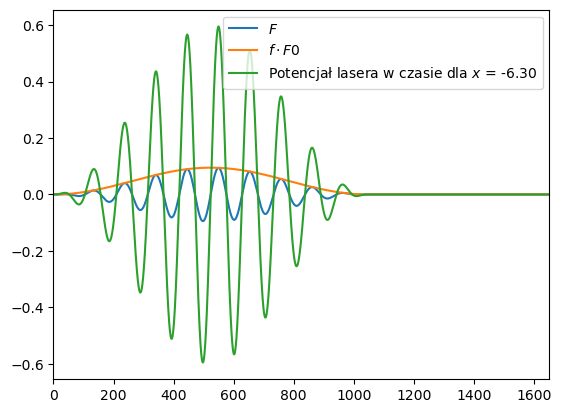

In [129]:
# --- Wykres diagnostyczny profilu czasowego impulsu laserowego ---

# Rysowanie pełnego, oscylującego pola elektrycznego F(t) lasera
plt.plot(t_values, F, label = r"$F$")

# Rysowanie samej obwiedni impulsu przeskalowanej przez maksymalną amplitudę F0
plt.plot(t_values, f * F0, label = r"$f\cdot F0$")

# Ustawienie sztywnego zakresu osi czasu od zera do końca symulacji
plt.xlim(t_values.min(), t_values.max())

# Wyświetlenie legendy oraz generowanie wykresu
plt.legend()
plt.show()

In [131]:
start = time.perf_counter()
# --- Parametry potencjału absorbującego (Complex Absorbing Potential - CAP) ---
# CAP zapobiega niefizycznym odbiciom częściowo zjonizowanego pakietu falowego od brzegów siatki obliczeniowej.

w = 0.05 * L       # Szerokość strefy absorpcyjnej po obu stronach dziedziny (5% całkowitego rozmiaru L)
x0 = L/2 - w       # Punkt rozpoczęcia pochłaniania na prawym brzegu układu
η0 = 1.0           # Maksymalna amplituda (współczynnik) potencjału absorbującego na krańcach siatki
alpha = 2          # Wykładnik potęgowy profilu tłumienia (profil kwadratowy zapewnia gładkie włączanie absorpcji)

# --- Konstrukcja profilu przestrzennego potencjału absorpcyjnego η(x) ---
η = np.zeros_like(x)

# Definicja maski i obliczenie profilu tłumienia dla prawego brzegu siatki
# Przesunięcie o 0.5 zabezpiecza numerycznie przed osobliwością na samym skraju
right_mask = x > (x0 - 0.5)
η[right_mask] = η0 * ((x[right_mask] - (x0 - 0.5)) / w)**alpha

# Definicja maski i obliczenie symetrycznego profilu tłumienia dla lewego brzegu siatki
left_mask = x < -(x0 - 0.5)
η[left_mask] = η0 * (((-x0 + 0.5) - x[left_mask]) / w)**alpha

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 0.000512 sekundy


In [132]:
start = time.perf_counter()

# --- Przygotowanie przestrzeni pędów dla Split-Operatora ---

# Wyznaczenie dyskretnych wektorów falowych (współrzędnych pędu k_x) skorelowanych z siatką przestrzenną
# Przeskalowanie o 2*pi wynika z definicji transformacji Fouriera w fizyce (k = 2 * pi / lambda)
kx = 2 * np.pi * fftfreq(Nx, dx)

# Obliczenie kwadratu wektora falowego (odpowiednik operatora energii kinetycznej p^2 w jednostkach atomowych)
K2 = kx**2

# --- Definicja kroków fazowych dla Split-Operatora ---

# Propagator energii kinetycznej w przestrzeni pędów (działa na połówce kroku czasowego: dt/2)
# Wzór: exp(-i * (p^2 / 2) * (dt / 2)) = exp(-i * (K2 / 4) * dt)
T_phase = np.exp(-1j * (K2 / 4) * dt)

# Propagator potencjału Coulombowskiego w przestrzeni rzeczywistej (na pełnym kroku dt)
V_phase_0 = np.exp(-1j * V0 * dt)

# Człon tłumiący realizujący działanie potencjału absorpcyjnego CAP
η_phase = np.exp(- η * dt)

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 0.000951 sekundy


In [133]:
start = time.perf_counter()

# Inicjalizacja listy do zapisu ewolucji funkcji falowej w dyskretnych chwilach czasu
psi_t = []  

# --- Główna pętla propagacji czasowej (Rozwiązanie zależnego od czasu równania Schrödingera - TDSE) ---
for step in range(Nt):
    
    # === 1. PIERWSZY PÓŁKROK EWOLUCJI ENERGII KINETYCZNEJ (Przestrzeń pędów) ===
    # Transformacja Fouriera funkcji falowej do przestrzeni pędów
    ψ_temp = fft(ψ)
    # Nałożenie propagatora kinetycznego na połówce kroku czasowego (dt/2)
    ψ_temp *= T_phase
    # Powrót transformatą odwrotną do przestrzeni rzeczywistej
    ψ = ifft(ψ_temp)

    # === 2. PEŁNY KROK EWOLUCJI POTENCJAŁU I ABSORPCJI (Przestrzeń rzeczywista) ===
    # Wyznaczenie dynamicznego, całkowitego propagatora potencjału w chwili 'step'
    # Składa się z niezależnego od czasu potencjału atomowego (V_phase_0) oraz zmiennego pola lasera V_laser
    V_phase = V_phase_0 * np.exp(-1j * (V_laser[:, step]) * dt)
    
    # Modyfikacja fazy funkcji falowej przez wypadkowy potencjał (pełny krok dt)
    ψ *= V_phase
    
    # Aplikacja warunku brzegowego CAP
    ψ *= η_phase

    # === 3. DRUGI PÓŁKROK EWOLUCJI ENERGII KINETYCZNEJ (Przestrzeń pędów) ===
    # Ponowna transformacja do przestrzeni pędów dla domknięcia symetrycznego schematu Suzuki-Trottera
    ψ_temp = fft(ψ)
    # Nałożenie drugiego operatora kinetycznego na połówce kroku czasowego (dt/2)
    ψ_temp *= T_phase
    # Powrót do przestrzeni rzeczywistej – zakończenie pełnego kroku ewolucji o czas dt
    ψ = ifft(ψ_temp)

    # Zapis aktualnego stanu funkcji falowej do historii ewolucji
    psi_t.append(ψ)


# Konwersja listy funkcji falowych w każdym kroku czasowym na dwuwymiarową macierz NumPy (część rzeczywista i urojona)
# Wymiary macierzy: (Nt x Nx)
psi_t = np.array(psi_t)

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 84.068454 sekundy


In [ ]:
start = time.perf_counter()

# --- Obliczanie przyspieszenia elektronu dwiema metodami ---

# Analityczna pochodna wygładzonego potencjału Coulomba po położeniu: dV0/dx.
# Odpowiada sile oddziaływania elektron-jądro.
dV0_dx = x / np.sqrt((x**2 + epsilon)**3)

# --- Metoda 1: Obliczenie przyspieszenia elektronu z twierdzenia Ehrenfesta ---
# Wzór: a(t) = F_laser(t) * <ψ(t)|ψ(t)> - <ψ(t)| dV0/dx |ψ(t)>
# <ψ(t)|ψ(t)> nie jest równe 1 przez CAP, który pochłania część funkcji falowej w trakcie jej ewolucji w czasie.
# np.sum(..., axis=1) realizuje całkowanie numeryczne po całej przestrzeni x w każdej chwili czasu t.
a_t_Ehr = F * np.sum(np.abs(psi_t)**2, axis=1) - np.sum(np.abs(psi_t)**2 * dV0_dx, axis=1)

# --- Metoda 2: Obliczenie przyspieszenia elektronu z numerycznego różniczkowania momentu dipolowego ---
# Obliczenie wartości oczekiwanej operatora położenia: <x>(t) = <ψ(t)| x |ψ(t)>
x_avg_t = np.sum(np.abs(psi_t)**2 * x, axis=1)

# Wyznaczenie drugiej pochodnej średniego położenia po czasie przy użyciu ilorazów różnicowych (np.diff).
a_t_dipole = np.diff(np.diff(x_avg_t) / dt) / dt

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

In [134]:
start = time.perf_counter()

# --- Obliczanie stopnia jonizacji układu jako funkcji czasu ---

# Definicja umownego promienia atomu wyrażona w jednostkach atomowych (promieniach Bohra, a_0)
N_Bohr = 80   
# Maska wycinająca z przestrzeni symulacji przedział [-80, 80] należący do atomu
mask_atom = (x >= -N_Bohr) & (x <= N_Bohr)

# Obliczenie gęstości prawdopodobieństwa |ψ(x,t)|^2 ograniczonej wyłącznie do zdefiniowanego obszaru atomu
prob_density = np.abs(psi_t[:, mask_atom])**2

# Całkowanie numeryczne (sumowanie) gęstości prawdopodobieństwa wewnątrz atomu dla każdego kroku czasowego
# Wynik to prawdopodobieństwo znalezienia elektronu w stanie związanym w danej chwili t
prob_inside = np.sum(prob_density, axis=1)

# Obliczenie prawdopodobieństwa jonizacji (prawdopodobieństwa znalezienia elektronu poza atomem)
# Wzór: P_ion(t) = 1 - P_inside(t). Ponieważ CAP sztucznie wygasza funkcję na brzegach, 
# odejmowanie od teoretycznej jedności (1) odzwierciedla realny ubytek populacji ze stanu związanego.
ionization_t = 1 - prob_inside

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 25.254475 sekundy


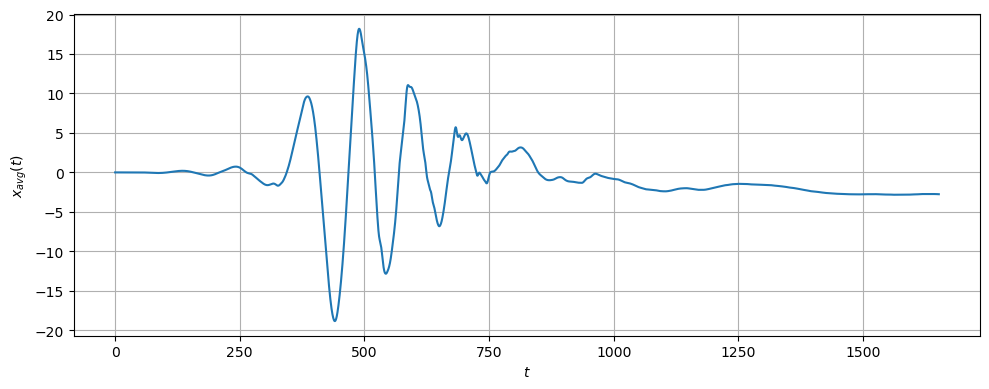

In [135]:
# --- Wykres ewolucji średniego położenia pakietu falowego ---

plt.figure(figsize=(10, 4))

# Rysowanie zmian średniego położenia <x(t)> w czasie (odpowiednik momentu dipolowego)
plt.plot(t_values, x_avg_t)

# Opis osi z wykorzystaniem notacji LaTeX (t - czas, x_avg(t) - wartość oczekiwana położenia)
plt.xlabel("$t$")
plt.ylabel(r"$x_{avg}(t)$")

# Włączenie siatki pomocniczej ułatwiającej odczyt częstotliwości i amplitudy drgań
plt.grid(True)
plt.tight_layout()
plt.show()

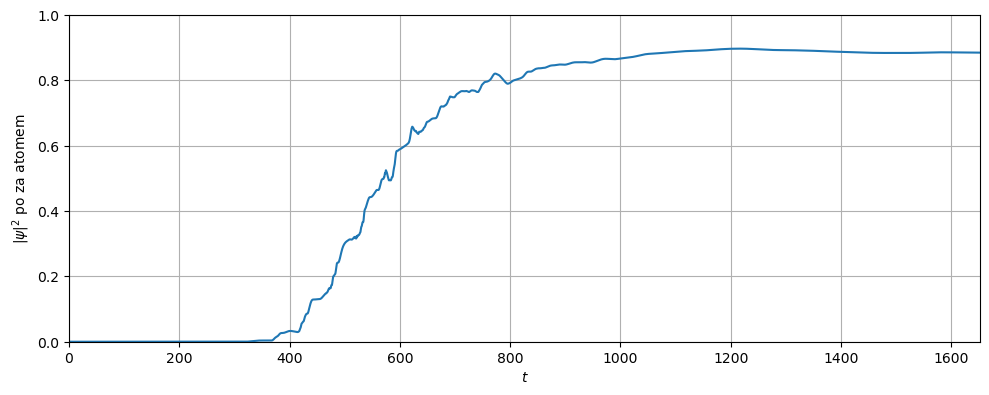

In [136]:
# --- Wykres ewolucji stopnia jonizacji pakietu falowego ---

plt.figure(figsize=(10, 4))

# Rysowanie zmian prawdopodobieństwa jonizacji (populacji poza obszarem atomu) w funkcji czasu
plt.plot(t_values, ionization_t)

# Opis osi z wykorzystaniem notacji LaTeX
plt.xlabel("$t$")
plt.ylabel(r"$|\psi|^2$ poza atomem")

plt.grid(True)
plt.tight_layout()

# Ustawienie sztywnych granic osi w celu prezentacji pełnego okna czasowego i pełnego zakresu prawdopodobieństwa [0, 1]
plt.xlim(0, np.max(t_values))
plt.ylim(0, 1)
plt.show()

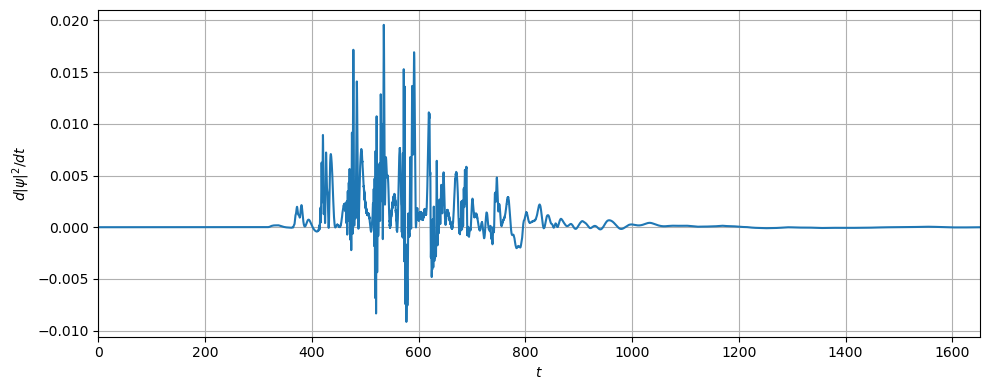

In [137]:
# --- Obliczenie i wykres tempa jonizacji (ionization rate) ---
# Pochodna stopnia jonizacji po czasie pozwala zidentyfikować chwile maksymalnej emisji elektronów w cyklu laserowym

# Obliczenie tempa jonizacji za pomocą pochodnej po czasie stopnia jonizacji
ionization_rate = np.gradient(ionization_t, dt)

plt.figure(figsize=(10, 4))

# Rysowanie tempa jonizacji. Oś czasu t_values zostaje skrócona o jeden punkt [:-1], 
# ponieważ operacja np.diff zmniejsza rozmiar tablicy wynikowej o 1.
plt.plot(t_values, ionization_rate)

# Opis osi z wykorzystaniem zapisu pochodnej w notacji LaTeX
plt.xlabel("$t$")
plt.ylabel(r"$d|\psi|^2/dt$")

plt.grid(True)
plt.tight_layout()

# Ustawienie stałego zakresu dla osi czasu
plt.xlim(0, np.max(t_values))
plt.show()

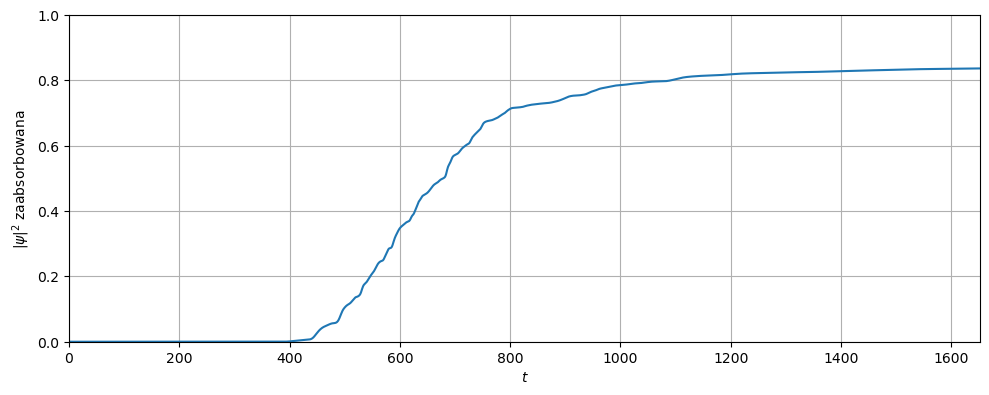

In [138]:
# --- Obliczenie i wykres całkowitej normy zaabsorbowanej przez CAP ---
# Wartość ta reprezentuje ładunek (część pakietu falowego), który opuścił siatkę obliczeniową.
# W przeciwieństwie do ionization_t (opartej na masce atomu), ten wskaźnik mierzy wyłącznie gęstość, która fizycznie dotarła do brzegów układu i została pochłonięta.
absorbed_electron = 1 - np.sum(np.abs(psi_t)**2, axis=1)

plt.figure(figsize=(10, 4))

# Rysowanie skumulowanej zaabsorbowanej gęstości prawdopodobieństwa w czasie
plt.plot(t_values, absorbed_electron)

plt.xlabel("$t$")
plt.ylabel(r"$|\psi|^2$ zaabsorbowana")
plt.grid(True)
plt.tight_layout()

# Ustawienie stałych granic osi
plt.xlim(0, np.max(t_values))
plt.ylim(0, 1)
plt.show()

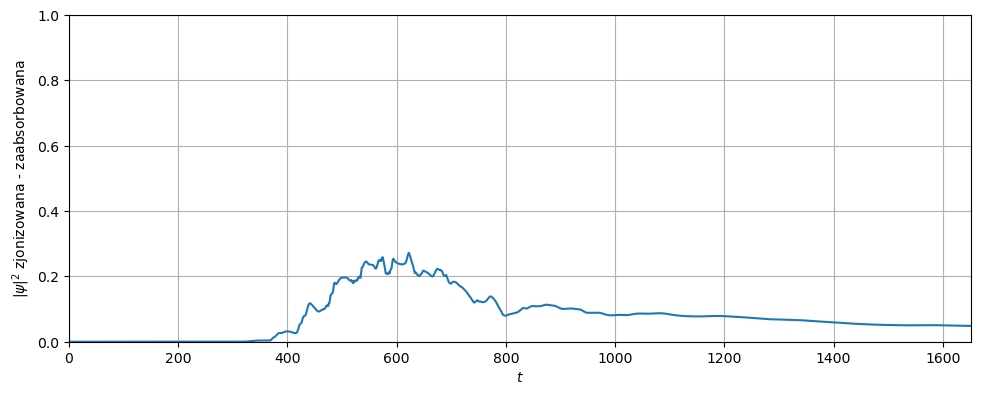

In [139]:
# --- Obliczenie i wykres niezaobsorbowanej zjonizowanej gęstości prawdopodobieństwa ---
# Samo obliczenie
left_electron = ionization_t - absorbed_electron

plt.figure(figsize=(10, 4))

# Rysowanie ilości ładunku znajdującego się w "locie" w funkcji czasu
plt.plot(t_values, left_electron)

plt.xlabel("$t$")
plt.ylabel(r"$|\psi|^2$ zjonizowana - zaabsorbowana")
plt.grid(True)
plt.tight_layout()

# Ustawienie stałych granic osi
plt.xlim(0, np.max(t_values))
plt.ylim(0, 1)
plt.show()

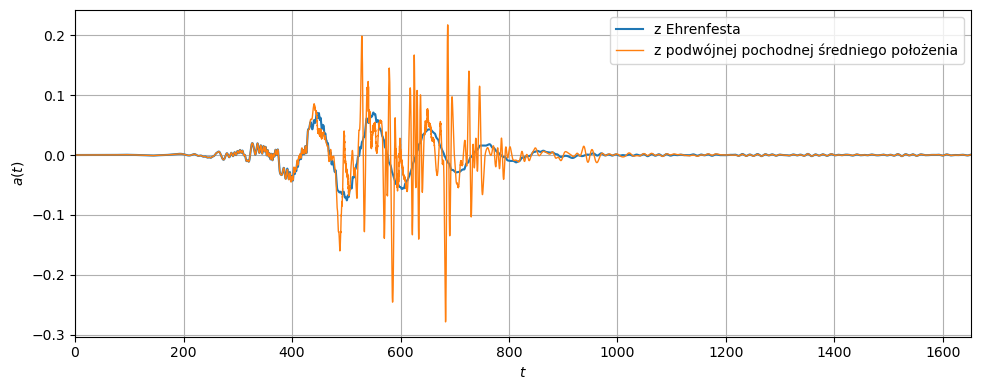

In [141]:
# --- Porównanie metod wyznaczania przyspieszenia elektronu w czasie ---
# Wykres zestawia wyniki uzyskane metodami przez tw. Ehrenfesta i drugą pochodną położenia.

plt.figure(figsize=(10, 4))

# Rysowanie części rzeczywistej przyspieszenia obliczonego bezpośrednio z tw. Ehrenfesta
plt.plot(t_values, a_t.real, label='z Ehrenfesta')

plt.xlabel("$t$")
plt.ylabel(r"$a(t)$")
plt.grid(True)
plt.tight_layout()
plt.xlim(0, t_values.max())

# Rysowanie przyspieszenia jako drugiej pochodnej czasowej momentu dipolowego.
# Oś czasu zostaje skrócona o dwa punkty [:-2], ponieważ dwukrotne użycie np.diff zmniejsza rozmiar tablicy o 2.
# Użyto cieńszej linii (lw=1), aby nałożone wykresy były czytelne i pozwalały dostrzec ewentualne rozbieżności.
plt.plot(t_values[:-2], a_t_from_dipole.real, lw=1, label='z podwójnej pochodnej średniego położenia')

# Wyświetlenie legendy identyfikującej obie metody badawcze
plt.legend()
plt.show()

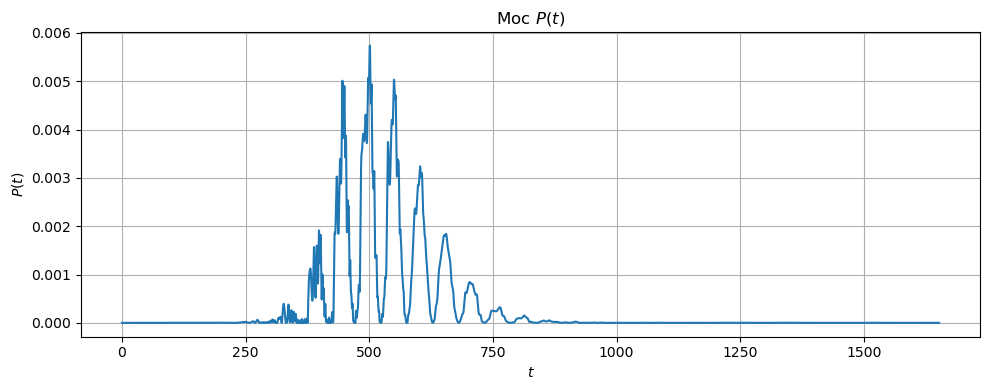

In [143]:
# --- Wykres ewolucji mocy promieniowania ---

plt.figure(figsize=(10, 4))

# Rysowanie przebiegu mocy P(t) w funkcji czasu
plt.plot(t_values, P_t)

plt.xlabel("$t$")
plt.ylabel(r"$P(t)$")
plt.title("Moc $P(t)$")
plt.grid(True)
plt.tight_layout()

# Ustawienie stałego zakresu dla osi czasu
plt.xlim(0, np.max(t_values))
plt.show()

In [144]:
start = time.perf_counter()
# --- Transformata Fouriera przyspieszenia - wyznaczenie widma HHG ---
# Przejście z dziedziny czasu do dziedziny częstości

# Obliczenie transformaty Fouriera (FFT) przyspieszenia elektronu
a_omega = fft(a_t)

# Wyznaczenie dyskretnych częstotliwości próbkowania
freqs = fftfreq(Nt, dt)  

# Widmo mocy emisji z tw. Ehrenfesta
P_omega = np.abs(a_omega)**2

# Przeskalowanie osi częstotliwości (współrzędnych fourierowskich) na jednostki energii fotonu
# Wyrażenie częstości w wielokrotnościach częstości lasera podstawowego (omega/omega_0) pozwala bezpośrednio odczytać rzędy harmonicznych (1, 3, 5...)
omegas = 2 * np.pi * freqs / omega_0


# --- Centrowanie widma fourierowskiego ---
# Standardowo funkcja fft() układa częstotliwości w kolejności: najpierw dodatnie, potem ujemne.
# Funkcja np.fft.fftshift() przenosi składową stałą (częstotliwość zerową) na środek tablicy,
# co pozwala na naturalne i intuicyjne rysowanie wykresów spektralnych (od ujemnych do dodatnich częstotliwości).

omegas = np.fft.fftshift(omegas)
a_omega = np.fft.fftshift(a_omega)
P_omega = np.fft.fftshift(P_omega)

end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 0.029526 sekundy


In [147]:
start = time.perf_counter()
# --- Transformata Fouriera dla pochodnej dipola ---
# Obliczenie widma HHG przy użyciu drugiej pochodnej średniego położenia.

# Obliczenie FFT z przyspieszenia wyznaczonego poprzez różniczkowanie momentu dipolowego
a_omega_dipole = fft(a_t_from_dipole)

# Korekta osi częstotliwości dla pochodnej dipola.
# Ponieważ tablica a_t_from_dipole jest krótsza o 2 elementy (wynik dwukrotnego np.diff),
# jej transformata wymaga dopasowania siatki omegas. Dodatkowo wprowadzane jest przesunięcie 
# o jeden krok siatki fourierowskiej w celu synchronizacji fazowej obu metod.
omegas_dipole = (omegas[:-2] + (omegas[1] - omegas[0]))

# Widmo mocy emisji z metody dipolowej
P_omega_dipole = np.abs(a_omega_dipole)**2

# Przeniesienie składowej stałej na środek tablicy
P_omega_dipole = np.fft.fftshift(P_omega_dipole)


end = time.perf_counter()
print(f"Czas działania: {end - start:.6f} sekundy")

Czas działania: 0.029389 sekundy


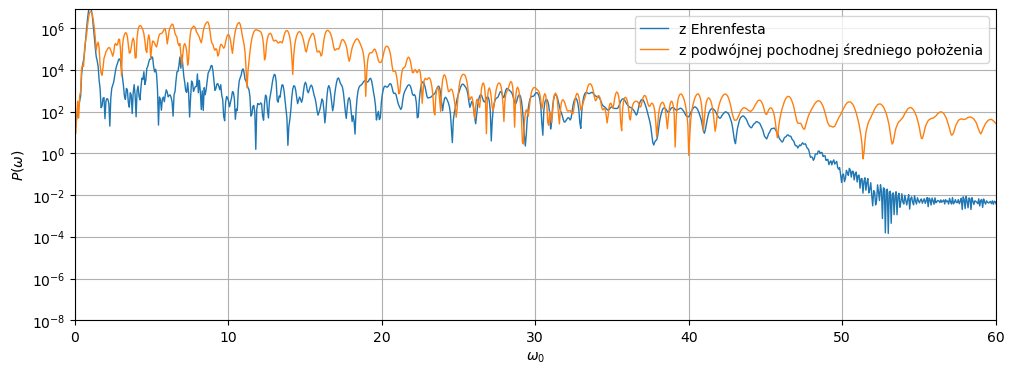

In [153]:
# --- Porównawczy wykres widma generacji wysokich harmonicznych (HHG) ---
# Wykres przedstawia widmo mocy emisji w skali logarytmicznej w funkcji częstości (energii fotonu).
# Pozwala na identyfikację wygenerowanych harmonicznych oraz weryfikację spójności metod numerycznych.

plt.figure(figsize=(10, 4))

# Rysowanie widma z twierdzenia Ehrenfesta – tylko dla dodatnich częstotliwości (omegas > 0)
plt.plot(omegas[omegas > 0], P_omega[omegas > 0], lw=1, label='z Ehrenfesta')

# Ustawienie zakresu osi X (widoczny przedział rzędów harmonicznych, np. od 0 do 60)
plt.xlim(0, 60)

# Ustawienie zakresu osi Y w skali logarytmicznej
plt.ylim(1e-8, 8e6)

# Opis osi. 
plt.xlabel(r"$\omega [\omega_0]$")
plt.ylabel(r"$P(\omega)$")

# Skala logarytmiczna dla osi pionowej, niezbędna do poprawnej wizualizacji plateau i odcięcia (cutoff) widma HHG
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5) # Siatka dla skali logarytmicznej

# Rysowanie widma z pochodnej dipola – również wyłącznie dla częstotliwości dodatnich
plt.plot(omegas_dipole[omegas_dipole > 0], P_omega_dipole[omegas_dipole > 0], lw=1, label='z podwójnej pochodnej średniego położenia')

plt.legend()
plt.tight_layout()
plt.show()

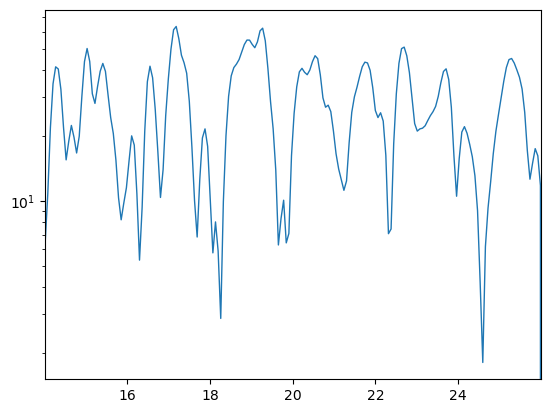

In [187]:
# --- Wycięcie fragmentu widma z tw. Ehrenfesta do generacji impulsu attosekundowego ---
# Definicja zakresu generacji harmonicznych, z których syntetyzowany będzie impuls attosekundowy
omegas_start = 14
omegas_end = 26

# Tworzenie maski logicznej dla wybranego przedziału częstotliwości dodatnich
attosecond_impulse_mask = (omegas > omegas_start) & (omegas < omegas_end)

# Inicjalizacja nowej tablicy spektralnej zerami o takim samym kształcie jak a_omega
a_omega_attosecond_impulse = np.zeros_like(a_omega)

# Przepisanie wartości zespolonych amplitudy przyspieszenia tylko dla odfiltrowanego pasma (reszta pozostaje wygaszona)
a_omega_attosecond_impulse[attosecond_impulse_mask] = a_omega[attosecond_impulse_mask]

# Wykres odfiltrowanego fragmentu widma
plt.plot(omegas, np.abs(a_omega_attosecond_impulse), lw=1, label='z Ehrenfesta')

# Zawężenie widoku osi X do granic wybranego pasma
plt.xlim(omegas_start + 0.0001, omegas_end - 0.001)
plt.yscale('log')

C:\Users\Maciej\miniforge3\envs\jupyterenv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Maciej\miniforge3\envs\jupyterenv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


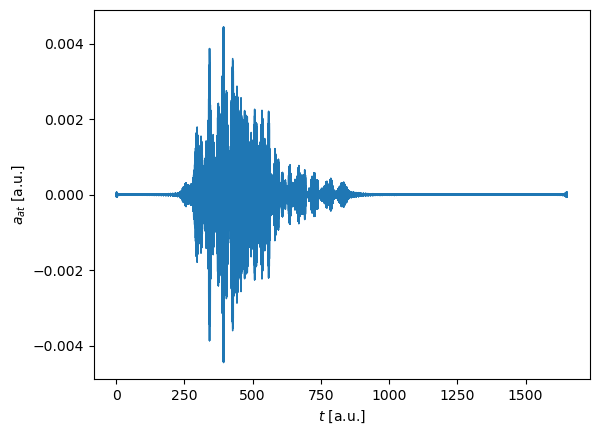

In [188]:
# --- Odwrotna transformata Fouriera – synteza impulsu attosekundowego ---
# Przejście z powrotem do dziedziny czasu (IFFT) po odfiltrowaniu konkretnego pasma częstości
# Generuje profil czasowy wyemitowanego pociągu impulsów attosekundowych

# Obliczenie odwrotnej transformaty Fouriera ze zmodyfikowanej amplitudy spektralnej
a_t_attosecond_impulse = ifft(a_omega_attosecond_impulse)

plt.figure(figsize=(10, 4))

# Rysowanie natężenia pola (przyspieszenia) impulsu attosekundowego.
plt.plot(t_values, a_t_attosecond_impulse.real, lw=1, label='z Ehrenfesta')

plt.xlabel("$t$ [a.u.]")
plt.ylabel(r"$a_{at}$ [a.u.]")
plt.grid(True)
plt.tight_layout()

# Zapis wygenerowanego impulsu do formatu PDF z uwzględnieniem przedziału odfiltrowanych harmonicznych w nazwie pliku
plt.savefig(f"a_at(t); E_{state_number}; F_0={F0}; n={n}; omega_0={omega_0}; omega = [{omegas_start}, {omegas_end}].pdf", bbox_inches='tight')
plt.show()

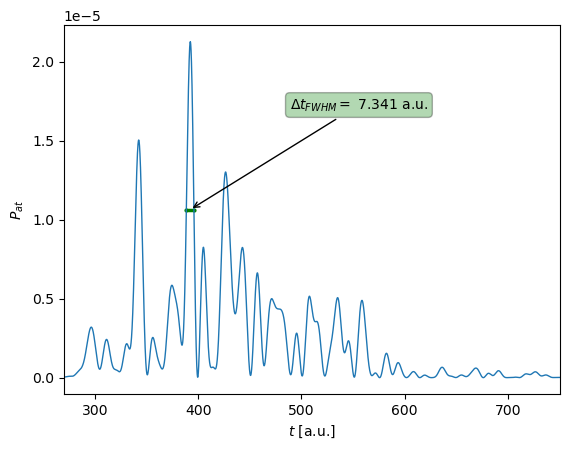

In [191]:
# --- Obliczenie natężenia impulsu attosekundowego oraz pomiar szerokości połówkowej (FWHM) ---
# Kod lokalizuje główny pik emisji attosekundowej i wyznacza jego szerokość FWHM (Full Width at Half Maximum)

# Moc impulsu attosekundowego
P_t_attosecond_impulse = np.abs(a_t_attosecond_impulse)**2

# --- Algorytm wyznaczania szerokości FWHM ---
# Znalezienie indeksu oraz wartości globalnego maksimum natężenia impulsu
idx_max = np.argmax(P_t_attosecond_impulse)
val_max = P_t_attosecond_impulse[idx_max]
half_max = val_max / 2.0

# Poszukiwanie lewego punktu przecięcia z poziomem połowy wysokości (half_max) w otoczeniu piku
left_idx = idx_max
while left_idx > 0 and P_t_attosecond_impulse[left_idx] > half_max:
    left_idx -= 1

# Poszukiwanie prawego punktu przecięcia z poziomem połowy wysokości w otoczeniu piku
right_idx = idx_max
while right_idx < len(P_t_attosecond_impulse) - 1 and P_t_attosecond_impulse[right_idx] > half_max:
    right_idx += 1

# Interpolacja indeksów na rzeczywiste wartości czasu z osi t_values
t_left = t_values[left_idx]
t_right = t_values[right_idx]

# Obliczenie szerokości połówkowej (FWHM) w jednostkach atomowych [a.u.]
fwhm_au = t_right - t_left


# --- Generowanie wykresu profilu czasowego z adnotacją FWHM ---
plt.figure(figsize=(10, 4))

# 1. Rysowanie poziomej linii reprezentującej szerokość FWHM na poziomie 50% wysokości piku
plt.hlines(y=half_max, xmin=t_left, xmax=t_right, colors='green', linestyles='-', lw=2.5, label='FWHM')

# 2. Wyznaczenie punktów brzegowych FWHM (zielone znaczniki na końcach linii)
plt.plot([t_left, t_right], [half_max, half_max], 'go', ms=2)

# 3. Dodanie dynamicznej adnotacji tekstowej ze strzałką celującą w środek linii FWHM
text_info = f"$\Delta t_{{FWHM}} = $ {fwhm_au:.3f} a.u."
t_center = (t_left + t_right) / 2

plt.annotate(text_info, 
             xy=(t_center, half_max), 
             xytext=(t_left + 100, half_max * 1.6), # Współrzędne położenia ramki z tekstem
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
             fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", fc="green", alpha=0.3))

# 4. Rysowanie profilu natężenia obwiedni impulsu attosekundowego
plt.plot(t_values, P_t_attosecond_impulse, lw=1, label='z Ehrenfesta')

plt.xlabel("$t$ [a.u.]")
plt.ylabel(r"$P_{at}$")

# Zawężenie osi X do obszaru występowania głównego piku (wartości dopasowane do okna emisji)
plt.xlim(270, 750)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# --- Przygotowanie i konfiguracja animacji ewolucji pakietu falowego ---
# Animacja przedstawia jednoczesną ewolucję gęstości prawdopodobieństwa elektronu 
# oraz oscylacje pełnego potencjału (studnia kulombowska + pole lasera) w czasie.

import matplotlib.animation as animation

fig, ax = plt.subplots()

# Inicjalizacja linii wykresu dla potencjału oraz gęstości prawdopodobieństwa.
# Dodano przesunięcia (offset), aby dopasować wykresy do skali logarytmicznej osi Y.
line_V, = ax.plot(x, V0 + 0.8, lw=1, label="V(x)")
line, = ax.plot(x, 15 * np.abs(psi_t[0])**2 + 0.3, lw=2, label=r"$|\psi(x,t)|^2$")

# Zawężenie widoku osi X, aby odciąć obszary brzegowe z absorberem CAP
ax.set_xlim(x.min() + 80, x.max() - 80)
ax.set_ylim(0.28, 1.3)

# Skala logarytmiczna pozwala na jednoczesną obserwację stanu związanego oraz 
# zjonizowanej części pakietu falowego o niskiej amplitudzie.
ax.set_yscale('log')

ax.set_xlabel("x")
ax.set_ylabel("$|\psi(t)|^2$")
ax.legend(loc="upper right")


def init():
    """Inicjalizacja danych wejściowych animacji (czyszczenie linii)."""
    line.set_data([], [])
    line_V.set_data([], [])
    return line, line_V


def update(frame):
    """Funkcja wywoływana cyklicznie dla każdej klatki animacji."""
    # Aktualizacja gęstości prawdopodobieństwa elektronu
    y = 15 * np.abs(psi_t[frame])**2 + 0.3
    line.set_data(x, y)
    
    # Aktualizacja profilu potencjału (uwzględnienie chwilowej wartości pola lasera)
    line_V.set_data(x, V0 + V_laser[:, frame] + 0.8)
    
    # Wyświetlanie aktualnego czasu symulacji w tytule wykresu
    ax.set_title(f"t = {t_values[frame]:.2f}")
    
    # Zwrócenie obu zmodyfikowanych obiektów (kluczowe dla poprawnego działania blit=True)
    return line, line_V


# Generowanie animacji. Krok próbkowania ramek (step=300) zapobiega nadmiernemu zużyciu pamięci RAM.
# Poprawiono parametr init_func i przekazywane obiekty w celach optymalizacji rysowania (blit).
ani = animation.FuncAnimation(
    fig, update, frames=range(0, Nt, 300), init_func=init, blit=True
)

plt.show()

In [272]:
# --- Zapis animacji do pliku wideo (MP4) przy użyciu standardu FFMpeg ---
# Konfiguracja i wywołanie procesu renderowania animacji ewolucji pakietu falowego.
# Wymaga zainstalowanego w systemie pakietu FFmpeg.

from matplotlib.animation import FFMpegWriter
import matplotlib as mpl

# Konfiguracja writera: 30 klatek na sekundę (fps) oraz wysoki bitrate zapewniający 
# płynność i brak artefaktów kompresji na wykresie gęstości prawdopodobieństwa.
writer = FFMpegWriter(fps=30, metadata=dict(artist='Me'), bitrate=2800)

# Uruchomienie procesu renderowania i zapisu do pliku wideo.
# Proces może zająć od kilkunastu sekund do kilku minut w zależności od liczby klatek (Nt).
ani.save("Studnia Coulombowska.mp4", writer=writer)